In [1]:
import os
import json
from astropy.cosmology import FlatwCDM
import os, sys
#import pymultinest
import re
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from astropy.table import Column
from scipy.stats import bootstrap
from getdist import plots, MCSamples
import scipy.optimize as op
from scipy import stats
from scipy.stats import norm
from astropy.time import Time
import matplotlib.dates as mdates
from joblib import Parallel, delayed
import time

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "text.latex.preamble": r"\usepackage{amssymb}"
})

In [2]:
class subset_creation:
    def __init__(self,
                 input_df,
                 condition,
                 subset_name):

        self.input_df = input_df
        self.condition = condition #Debe ser una lista de Tuplas
        self.subset_name = subset_name
        self.subset = None
        self.set_selection()

    def set_selection(self):
        tmp_dataFrame = pd.read_csv(self.input_df)
        for s in range(len(self.condition)):
            if self.condition[s][1] == '==':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.condition[s][0]]==self.condition[s][2]]
            elif self.condition[s][1] == '!=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.condition[s][0]]!=self.condition[s][2]]
            elif self.condition[s][1] == '>=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.condition[s][0]]>=self.condition[s][2]]
            elif self.condition[s][1] == '<=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.condition[s][0]]<=self.condition[s][2]]
            elif self.condition[s][1] == '>':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.condition[s][0]]>self.condition[s][2]]
            elif self.condition[s][1] == '<':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.condition[s][0]]<self.condition[s][2]]
        self.subset = tmp_dataFrame
        if len(self.subset) != 0:
            self.subset.to_csv(self.subset_name,index=False)

            galaxies = list(tmp_dataFrame['galaxy'].unique())


            main_folder_name = (self.subset_name).replace('.csv','')
            if not os.path.exists(main_folder_name):
                os.makedirs(main_folder_name, exist_ok=True)
                os.makedirs(f"{main_folder_name}/Bootstrap/", exist_ok=True)
                os.makedirs(f"{main_folder_name}/Nested_sampling/", exist_ok=True)
                os.makedirs(f"{main_folder_name}/Subplots/", exist_ok=True)
                os.makedirs(f"{main_folder_name}/Data/", exist_ok=True)

                for G in range(len(galaxies)):
                    os.makedirs(f"{main_folder_name}/Bootstrap/{galaxies[G]}/", exist_ok=True)
                    os.makedirs(f"{main_folder_name}/Nested_sampling/{galaxies[G]}/", exist_ok=True)
                    os.makedirs(f"{main_folder_name}/Subplots/{galaxies[G]}", exist_ok=True)



In [3]:
# 'Macri et al.2001' hubo que dejarlo fuera por que solo tenian medicion en una banda y estaban generando un outlier, cabria revisar si luego se puede incluir luego de RE-revisar el articulo original

subset_creation(input_df = 'PLRC_general_v1.1.csv',
                condition = [('metal_correction','==',False),('random_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'PLRC_nZ_eR.csv')
subset_creation(input_df = 'PLRC_general_v1.1.csv',
                condition = [('metal_correction','==',False),('total_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'PLRC_nZ_eT.csv')
subset_creation(input_df = 'PLRC_general_v1.1.csv',
                condition = [('metal_correction','==',True),('random_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'PLRC_Z_eR.csv')
subset_creation(input_df = 'PLRC_general_v1.1.csv',
                condition = [('metal_correction','==',True),('total_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'PLRC_Z_eT.csv')
subset_creation(input_df = 'TRGB_general_v1.1.csv',
                condition = [('random_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'TRGB_eR.csv')

In [4]:
subset_creation(input_df = 'PLRC_general_v1.1.csv',
                condition = [('random_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'PLRC_all_eR.csv')

In [6]:
DF_PLRC_general = pd.read_csv('PLRC_general_v1.1.csv')
DF_PLRC_trgb = pd.read_csv('TRGB_general_v1.1.csv')
DF_JOINT = pd.concat([DF_PLRC_general, DF_PLRC_trgb], join='inner', ignore_index=True)

DF_JOINT.to_csv('JOINT_general_v1.1.csv',index=False)


In [7]:
DF_JOINT

,galaxy,bibcode,citation,band,modulus,random_error,probe_quality,publication_year,review_year,comments,review_author,ads_date,ads_jd
0,IC0010,2000ApJ...529..745F,Ferrarese et al.2000,W(VI),24.100,0.190,1,2000,2024,There are no specific comments on the publicat...,Valencia et al.2024,2000-02-00,2451575.5
1,M33,2000ApJ...529..745F,Ferrarese et al.2000,VI,24.640,0.090,1,2000,2024,They calculate gamma.,Valencia et al.2024,2000-02-00,2451575.5
2,M33,2001ApJ...548..564W,Willick & Batra 2001,W(VI),24.470,0.130,1,2001,2024,They do not apply correction for metallicity.,Valencia et al.2024,2001-02-00,2451941.5
3,M33,2001ApJ...553...47F,Freedman et al.2001,W(VI),24.560,0.100,1,2001,2024,There are no specific comments on the publicat...,Valencia et al.2024,2001-05-00,2452030.5
4,M33,2001ApJ...553...47F,Freedman et al.2001,W(VI),24.620,0.100,1,2001,2024,Correction for metallicity and same uncertaint...,Valencia et al.2024,2001-05-00,2452030.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,NGC5584,2017ApJ...836...74J,Jang & Lee 2017,QT(F555W F814W),31.751,0.049,1,2017,2026,Preferred combined-anchor QT solution from the...,Quintero-Salazar et al.2026,2017-02-00,2457785.5
541,NGC5584,2017ApJ...836...74J,Jang & Lee 2017,F814W(F555W F814W),31.784,0.060,1,2017,2026,Combined-anchor blue-I solution from uniformly...,Quintero-Salazar et al.2026,2017-02-00,2457785.5
542,NGC5584,2024ApJ...966...89A,Anand et al. 2024,F090W(F090W F150W),31.800,0.080,1,2024,2026,Preliminary JWST result using a method-matched...,Quintero-Salazar et al.2026,2024-05-00,2460431.5
543,NGC5584,2024ApJ...976..177L,Li et al. 2024,F090W(F090W F150W),31.800,0.110,1,2024,2026,Baseline s=0.05 mag smoothing selects the brig...,Quintero-Salazar et al.2026,2024-12-00,2460645.5


In [5]:
# Este subset hay que crearlo a mano, solo dejando las columnas de random error y modulus en Cefeidas y TRGB
# Se utiliza la clase de subset para la creacion de carpetas y subcarpetas

subset_creation(input_df = 'JOINT_general_v1.1.csv',
                condition = [('random_error','>=',0),('citation','!=','Macri et al.2001')],
                subset_name = 'Joint_eR.csv')

In [9]:
DF_JOINT[DF_JOINT['random_error'].isna()]

,galaxy,bibcode,citation,band,modulus,random_error,probe_quality,publication_year,review_year,comments,review_author,ads_date,ads_jd
184,NGC6822,2012MNRAS.421.2998F,Feast et al.2012,W(VI),23.34,NaN,3,2012,2024,They mention that the error already contains t...,Valencia et al.2024,2012-04-00,2456018.5
185,NGC6822,2012MNRAS.421.2998F,Feast et al.2012,3.6micras,23.36,NaN,3,2012,2024,There are no specific comments on the publicat...,Valencia et al.2024,2012-04-00,2456018.5
186,NGC6822,2012MNRAS.421.2998F,Feast et al.2012,5.8micras,23.37,NaN,3,2012,2024,There are no specific comments on the publicat...,Valencia et al.2024,2012-04-00,2456018.5
187,NGC6822,2012MNRAS.421.2998F,Feast et al.2012,4.5micras,23.40,NaN,3,2012,2024,There are no specific comments on the publicat...,Valencia et al.2024,2012-04-00,2456018.5
188,NGC6822,2012MNRAS.421.2998F,Feast et al.2012,8micras,23.40,NaN,3,2012,2024,There are no specific comments on the publicat...,Valencia et al.2024,2012-04-00,2456018.5
189,NGC6822,2012MNRAS.421.2998F,Feast et al.2012,JKs,23.42,NaN,3,2012,2024,They mention that the error already contains t...,Valencia et al.2024,2012-04-00,2456018.5


In [10]:
DF_PLRC = pd.read_csv('PLRC_general_v1.1.csv')


DF_PLRC[DF_PLRC['comments'].isna()]

,galaxy,bibcode,citation,band,modulus,random_error,systematic_error,total_error,category_error,cepheids_number,metal_correction,anchor,probe_quality,publication_year,review_year,comments,review_author,ads_date,ads_jd
168,NGC4258,2014MNRAS.440.1138E,Efstathiou 2014,W(VI),29.24,0.08,NaN,NaN,1,120,True,GC,3,2014,2024,NaN,Valencia et al.2024,2014-05-00,2456778.5


In [85]:
DF_PLRC_general['anchor'].unique()

array(['LMC', 'GC', 'LMC+GC', 'N4258', 'LMC+GC+N4258', 'TM'], dtype=object)

In [86]:
# LMC
anchor_sel = DF_PLRC_general[DF_PLRC_general['anchor']=='LMC']
print(f"Records: {len(anchor_sel)} , Galaxies: {len(anchor_sel['galaxy'].unique())}")

Records: 241 , Galaxies: 24


In [87]:
# GC
anchor_sel = DF_PLRC_general[DF_PLRC_general['anchor']=='GC']
print(f"Records: {len(anchor_sel)} , Galaxies: {len(anchor_sel['galaxy'].unique())}")

Records: 75 , Galaxies: 19


In [88]:
# N4258
anchor_sel = DF_PLRC_general[DF_PLRC_general['anchor']=='N4258']
print(f"Records: {len(anchor_sel)} , Galaxies: {len(anchor_sel['galaxy'].unique())}")

Records: 7 , Galaxies: 5


In [89]:
# TM
anchor_sel = DF_PLRC_general[DF_PLRC_general['anchor']=='TM']
print(f"Records: {len(anchor_sel)} , Galaxies: {len(anchor_sel['galaxy'].unique())}")

Records: 8 , Galaxies: 2


In [90]:
# LMC+GC
anchor_sel = DF_PLRC_general[(DF_PLRC_general['anchor']=='GC+LMC') | (DF_PLRC_general['anchor']=='LMC+GC')]
print(f"Records: {len(anchor_sel)} , Galaxies: {len(anchor_sel['galaxy'].unique())}")

Records: 21 , Galaxies: 19


In [93]:
# N4258+GC+LMC
anchor_sel = DF_PLRC_general[(DF_PLRC_general['anchor']=='N4258+GC+LMC') | (DF_PLRC_general['anchor']=='N4258+LMC+GC') | (DF_PLRC_general['anchor']=='LMC+GC+N4258')]
print(f"Records: {len(anchor_sel)} , Galaxies: {len(anchor_sel['galaxy'].unique())}")

Records: 11 , Galaxies: 4


In [94]:
11+21+8+7+75+241


363

In [284]:

class moduli_stats_calculator:
    def __init__(self,
                 dataset=None,
                 error_selection='random_error',
                 galaxy_name=None,
                 multinest_steps = 5000,
                 bootstrap_steps = 200000):

        self.dataset = dataset
        self.error_selection = error_selection
        self.galaxy_name = galaxy_name
        self.multinest_steps = multinest_steps
        self.bootstrap_steps = bootstrap_steps

        self.input_data_frame = self.check_data()

        if self.input_data_frame is not None:
            self.moduli = np.array(self.input_data_frame['modulus'])
            self.moduli_error = np.array(self.input_data_frame[error_selection])
            self.N_records = len(self.input_data_frame)

            if self.N_records >= 2:
                BOOTSTRAP = self.bootstrap_error()
                NESTED_SAMPLING = self.nestedsampling_error() 

                self.mu_W = self.weighted_average()
                self.mu_B = BOOTSTRAP[0]
                self.mu_L = NESTED_SAMPLING[0]

                self.sigma_W = self.weighted_error()
                self.sigma_B = BOOTSTRAP[1]
                self.sigma_C = self.cochran_error()
                self.sigma_cl_plus = BOOTSTRAP[2][0]
                self.sigma_cl_minus = BOOTSTRAP[2][1]
                self.sigma_L = NESTED_SAMPLING[1]
                self.sigma_Lcorr = NESTED_SAMPLING[2]

                self.DISTRIBUTION_BOOTSTRAP = BOOTSTRAP[3]
                self.DISTRIBUTION_NESTED_SAMPLING = NESTED_SAMPLING[3]

            else:
                self.mu_W = self.weighted_average()
                self.mu_B = np.nan
                self.mu_L = np.nan

                self.sigma_W = self.weighted_error()
                self.sigma_B = np.nan
                self.sigma_C = self.cochran_error()
                self.sigma_cl_plus = np.nan
                self.sigma_cl_minus = np.nan
                self.sigma_L = np.nan
                self.sigma_Lcorr = np.nan            

            self.summary_stats()
            self.summary_plot()
            self.forest_plot()
            self.main_dist_plot()
            self.pdf_arts_plot()



    def check_data(self):
        """
        Funcion para checkear que toda la informacion esta bien y separar informacion por galaxia.
        """
        if self.dataset != None:
            data_frame = pd.read_csv(self.dataset)
            column_list = list(data_frame.columns)
            if not self.error_selection in column_list:
                print('Error selection not found in data frame')
                return None
            else:
                galaxy_subframe = data_frame[data_frame['galaxy']==self.galaxy_name]
                if len(galaxy_subframe) == 0:
                    print('Galaxy not found')
                    return None
                else:
                    galaxy_subframe.to_csv(f'{self.dataset.replace('.csv','')}/{self.galaxy_name}_data.csv',index=False)
                    return galaxy_subframe




    def weighted_average(self):
        """
        Computo del promedio ponderado
        """
        modulus,error = self.moduli,self.moduli_error
        err_sq_inv = 1 / ((error)**2)
        num = np.sum(err_sq_inv * modulus)
        dem = np.sum(err_sq_inv)
        return num/dem

    def weighted_error(self):
        """
        Computo del error ponderado
        """
        error = self.moduli_error
        err_sq_inv = 1 / ((error)**2)
        dem = np.sum(err_sq_inv)
        return 1 / np.sqrt(dem)

    def bootstrap_error(self):
        """
        Computo del promedio, error, distribucion y percentiles mediante bootstrap
        """
        def weighted_average_x_bootstrap(modulus,error):
            modulus,error = np.array(modulus),np.array(error)
            err_sq_inv = 1 / ((error)**2)
            num = np.sum(err_sq_inv * modulus)
            dem = np.sum(err_sq_inv)
            return num/dem
        PATH = f'{self.dataset.replace('.csv','')}/Bootstrap/{self.galaxy_name}/{self.galaxy_name}.txt'
        if os.path.exists(PATH) == True:
            bootstrap_statistics = np.loadtxt(PATH)
            print(f'Reading bootstrap for {self.galaxy_name}\n')
        if os.path.exists(PATH) == False:
            print(f'Running bootstrap for {self.galaxy_name}\n')
            modulus,error = self.moduli,self.moduli_error
            size = len(modulus)
            n_bootstraps = self.bootstrap_steps  # Number of bootstrap iterations
            bootstrap_statistics = []
            for i in range(n_bootstraps):
                # Create a resample with replacement, same size as original data
                bootstrap_sample = np.random.choice(size, size=size, replace=True)
                modulus_sample = modulus[bootstrap_sample]
                error_sample = error[bootstrap_sample]
                sample_mean = weighted_average_x_bootstrap(modulus_sample,error_sample)
                bootstrap_statistics.append(sample_mean)
            bootstrap_statistics = np.array(bootstrap_statistics)
            np.savetxt(fname = PATH, X = bootstrap_statistics)

        N_dist = len(bootstrap_statistics)
        br_mean = np.mean(bootstrap_statistics)
        quad_br = (bootstrap_statistics-br_mean)**2
        lower_bound = np.percentile(bootstrap_statistics, 15.87)
        upper_bound = np.percentile(bootstrap_statistics, 84.13)

        return [br_mean,
            np.sqrt(((1)/(N_dist-1)) * np.sum(quad_br)),
            [br_mean - lower_bound, upper_bound - br_mean],
            bootstrap_statistics]




    def cochran_error(self):
        """
        Computo del error mediante el metodo de Cochran
        """
        def weighted_average_x_cochran(modulus,error):
            err_sq_inv = 1 / ((error)**2)
            num = np.sum(err_sq_inv * modulus)
            dem = np.sum(err_sq_inv)
            return num/dem
        Mu_i,Er_i = self.moduli,self.moduli_error
        n = len(Mu_i)
        w_i = 1 / ((Er_i)**2)
        Mu_w = weighted_average_x_cochran(Mu_i,Er_i)
        w_mean = np.mean(w_i)

        s1 = n / ((n-1) * (np.sum(w_i))**2)
        s2 = (w_i * Mu_i  - (w_mean * Mu_w))**2
        s3 = (w_i - w_mean) * ((w_i*Mu_i) - (w_mean*Mu_w)) 
        s4 = (w_i - w_mean)**2

        return np.sqrt(s1 * (np.sum(s2) - (2 * Mu_w * np.sum(s3)) +    (Mu_w**2 * np.sum(s4)) ) )




    def nestedsampling_error(self):
        """
        Computo del modulo de distancia y error mediante Nested Sampling
        """
        modulus,error = self.moduli,self.moduli_error

        def prior_transform(x):
            mu = 20 * x + 20
            return mu
        
        def lnlike(theta, m, merr):
            mu_pi = theta
            R = (mu_pi - m)
            W = 1.0/(merr**2)
            xsq = np.sum(R**2 * W)
            L = -0.5*xsq
            return L
        
        def loglike_for_mnest(theta):
            return lnlike(theta, modulus, error)
        
        outdir = os.path.join(self.dataset.replace('.csv',''), f'Nested_sampling/{self.galaxy_name}/')
        os.makedirs(outdir, exist_ok=True)
        prefix = os.path.join(outdir, self.galaxy_name)

        n_dims = 1
        result = pymultinest.solve(
            LogLikelihood=loglike_for_mnest,
            Prior=prior_transform,
            n_dims=n_dims,
            outputfiles_basename=prefix,
            evidence_tolerance=0.5,
            n_live_points=self.multinest_steps,
            multimodal=True,
            verbose=False,
        )

        samples = result["samples"] 
        T_sample = samples.T
        logL = np.array([loglike_for_mnest(s) for s in samples])
        chi2_map = -2.0*np.max(logL)
        N = len(modulus)   # número de datos
        k = n_dims         # parámetros del modelo
        nu = N - k
        chi2_red = chi2_map / nu
        sigma2_corr = T_sample.std() * chi2_red

        samples_x_weight  = pymultinest.analyse.Analyzer(n_params = 1, outputfiles_basename=prefix)
        mu_L = float(samples_x_weight.get_stats()['modes'][0]['mean'][0])

        mu_pi_samples = samples_x_weight.get_equal_weighted_posterior()[:,0]

        return [mu_L,T_sample.std(),sigma2_corr,mu_pi_samples]


    def summary_stats(self):
        """
        Calculadora de estadisticas y resumen de resultados.
        """

        PATH = os.path.join(self.dataset.replace('.csv',''), f'TRGB_eR_recal.csv')

        if not os.path.exists(PATH):
                column_x_emptyDF = ['galaxy','records','mu_W','mu_B','mu_L','sigma_W','sigma_B','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']
                Empty_DF = pd.DataFrame(columns=column_x_emptyDF)
                Empty_DF.to_csv(PATH,index=False)

        DF_comp_recal = pd.read_csv(PATH)
        if not self.galaxy_name in list(DF_comp_recal['galaxy']):
            new_row = pd.DataFrame({
                'galaxy': [self.galaxy_name],
                'records': [self.N_records],
                'mu_W': [self.mu_W],
                'mu_B': [self.mu_B],
                'mu_L': [self.mu_L],
                'sigma_W': [self.sigma_W],
                'sigma_B': [self.sigma_B],
                'sigma_C': [self.sigma_C],
                'sigma_cl+': [self.sigma_cl_plus],
                'sigma_cl-': [self.sigma_cl_minus],
                'sigma_L': [self.sigma_L],
                'sigma_Lcorr': [self.sigma_Lcorr]
            })
            DF_comp_recal = pd.concat([DF_comp_recal, new_row], ignore_index=True)
            DF_comp_recal.to_csv(PATH,index=False)




    def forest_plot(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.input_data_frame  is not None:
            ax.minorticks_on()


            for a,b,c,d,e in zip([self.mu_W, self.mu_B, self.mu_L], 
                               [self.sigma_W, self.sigma_B, self.sigma_L], 
                               ['black', 'gray', 'brown'], 
                               ['--','-',':'],
                               [r'$\mu_{w}$ = ',r'$\mu_{B}$ = ',r'$\mu_{\mathcal{L}}$ = ']):
                ax.axvline(x=a, 
                           color=c, 
                           linestyle=d, 
                           linewidth=0.8, 
                           alpha=0.7,
                           label=e+f"{a:.4f}"+r' $\pm$ '+f"{b:.4f}")


            def jitter_same_time(t, base_buffer=25):
                """
                Si hay repetidos en t, los separa con pequeños offsets en el eje x.
                base_buffer en unidades de t (si t es JD, esto son días).
                """
                t = np.asarray(t, dtype=float)
                t_out = t.copy()
                # buffer automático: ~0.5% de la mediana del espaciado entre fechas únicas
                if base_buffer is None:
                    tu = np.unique(t)
                    if len(tu) > 1:
                        dt = np.diff(np.sort(tu))
                        base_buffer = 0.005 * np.median(dt)  # ajusta (0.005–0.02) según densidad
                    else:
                        base_buffer = 1.0  # 1 día si todo cae en la misma fecha
                # para cada fecha repetida, asigna offsets simétricos: -k,...,0,...,+k
                for val in np.unique(t):
                    idx = np.where(t == val)[0]
                    if len(idx) > 1:
                        k = len(idx)
                        offsets = (np.arange(k) - (k - 1)/2.0) * base_buffer
                        t_out[idx] = val + offsets
                return t_out

            t = np.array(self.input_data_frame['ads_jd'])  # JD
            x = np.array(self.input_data_frame['modulus'])  # modulus
            s = np.array(self.input_data_frame[self.error_selection])

    
            ordr = np.argsort(t)
            t_sorted = np.asarray(t)[ordr]
            x_sorted = np.asarray(x)[ordr]
            s_sorted = np.asarray(s)[ordr]
    
            t_jit = jitter_same_time(t_sorted)
            t_datetime = Time(t_jit, format='jd').to_datetime()
    
            cmap = plt.cm.tab10   # buen colormap categórico
            author_color = {}     # autor -> color
            plotted_authors = set()


            for u in range(self.N_records):
                author = self.input_data_frame['citation'].iloc[u].replace('&', r'$\&$')
                # Asignar color si es la primera vez que aparece el autor
                if author not in author_color:
                    author_color[author] = cmap(len(author_color) % cmap.N)
                color = author_color[author]
                label = author if author not in plotted_authors else None

                ax.errorbar(
                    x = x_sorted[u],
                    y = t_datetime[u],
                    xerr = s_sorted[u],
                    fmt='o', 
                    markerfacecolor=color, # Puedes cambiar a 'white' si prefieres marcadores huecos
                    markeredgecolor=color,
                    ecolor=color, 
                    elinewidth=1.0,         # Líneas de error más delgadas y elegantes
                    capsize=2,              # Remates de error más sutiles
                    markersize=5,
                    color=color,
                    label=label
                )
                plotted_authors.add(author)


            ax.set_xlabel(r'Distance Modulus, $\mu$', fontsize=16)
            ax.set_ylabel(r'Publication Year', fontsize=16)
            ax.legend(loc='best', ncol=1)
            #ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


            PATH_img = os.path.join(self.dataset.replace('.csv',''), f'Subplots/{self.galaxy_name}/{self.galaxy_name}_forest_plot.png')
            fig = ax.get_figure() 
            fig.savefig(PATH_img, bbox_inches='tight')
        return ax


    def main_dist_plot(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.input_data_frame  is not None:
            binS = np.histogram_bin_edges(self.DISTRIBUTION_BOOTSTRAP, bins='doane')
            ax.hist(self.DISTRIBUTION_NESTED_SAMPLING, bins=binS, density=True, 
                    color='#1f77b4', alpha=0.7, label=r'$\mathcal{P} \,( \mu |D)$',histtype='step',linewidth=3)
            ax.hist(self.DISTRIBUTION_BOOTSTRAP, bins=binS, density=True, 
                    color="#3ab41f", alpha=0.7, label=r'$\mathcal{B} \,( \mu_w)$',histtype='step',linewidth=3)
            ax.set_ylabel(r'PDF [$\%$]', fontsize=15)
            ax.set_xlabel(r'$\mu$', fontsize=15)
            ax.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
            ax.minorticks_on()

            sigmas_loc = [0.6,0.5,0.4,0.3,0.2,0.1]
            sigmas_color = ["#b41f1f","#1f30b4","#b41faa","#090a08","#994607","#0d9edc"]
            sigma_val = [self.sigma_W,self.sigma_B,[self.sigma_cl_plus,self.sigma_cl_minus],self.sigma_C,self.sigma_L,self.sigma_Lcorr]
            label_sigma = [r'$\sigma_{w}$',r'$\sigma_{B}$',r'$\sigma_{cl{\pm}}$',r'$\sigma_{C}$',r'$\sigma_{\mathcal{L}}$',r'$\sigma_{\mathcal{L} corr}$']

            for A, B, C, D in zip(sigmas_loc,sigmas_color,sigma_val,label_sigma):

                line_height = ax.get_ylim()[1] * A

                if isinstance(C, list):
                    lower_limit = self.mu_W - C[1]
                    upper_limit = self.mu_W  + C[0]
                    ax.hlines(y=line_height, 
                        xmin=lower_limit, 
                        xmax=upper_limit,
                        alpha = 0.6,
                        linewidth=5,color = B, label = rf"{D}: $^{{+{C[0]:.3f}}}_{{-{C[1]:.3f}}}$")
                else:
                    lower_limit = self.mu_W - C
                    upper_limit = self.mu_W + C
                    ax.hlines(y=line_height, 
                        xmin=lower_limit, 
                        xmax=upper_limit,
                        alpha = 0.6,
                        linewidth=5,color = B, label=f'{D}: {C:.3f}')


                ax.vlines(x=lower_limit, 
                    ymin=line_height - (ax.get_ylim()[1]*0.02), 
                    ymax=line_height + (ax.get_ylim()[1]*0.02), 
                    alpha = 0.6,linestyles='-',
                    linewidth=3,color = B)
                ax.vlines(x=upper_limit, 
                        ymin=line_height - (ax.get_ylim()[1]*0.02), 
                        ymax=line_height + (ax.get_ylim()[1]*0.02), alpha = 0.6,
                        linewidth=3,color = B)
            ax.legend()




            PATH_img = os.path.join(self.dataset.replace('.csv',''), f'Subplots/{self.galaxy_name}/{self.galaxy_name}_distributions_plot.png')
            fig = ax.get_figure() 
            fig.savefig(PATH_img, bbox_inches='tight')
            return ax


    def pdf_arts_plot(self, ax=None,mode=0):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.input_data_frame  is not None:
            binS = np.histogram_bin_edges(self.DISTRIBUTION_BOOTSTRAP, bins='doane')
            ax.hist(self.DISTRIBUTION_NESTED_SAMPLING, bins=binS, density=True, 
                    color='#1f77b4', alpha=0.7, label=r'$\mathcal{P} \,( \mu |D)$',histtype='step',linewidth=3)
            ax.hist(self.DISTRIBUTION_BOOTSTRAP, bins=binS, density=True, 
                    color="#3ab41f", alpha=0.7, label=r'$\mathcal{B} \,( \mu_w)$',histtype='step',linewidth=3)
            ax.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
            ax.minorticks_on()
            ax.set_ylabel(r'PDF [$\%$]', fontsize=15)
            ax.set_xlabel(r'$\mu$', fontsize=15)

            br_hist_ran = np.linspace(binS.min(), binS.max(), 1000)


            left_border = []
            right_border = []

            for a,b in zip(self.moduli,self.moduli_error):
                tmp1 = a - b
                tmp2 = a + b
                left_border.append(tmp1)
                right_border.append(tmp2)

            range_prov = np.linspace(np.min(left_border),
                                    np.max(right_border),
                                    1000)

            cmap = plt.cm.tab10   # buen colormap categórico
            author_color = {}     # autor -> color
            plotted_authors = set()

            sigma = np.array(self.input_data_frame[self.error_selection])
            for u in range(self.N_records):
                author = self.input_data_frame['citation'].iloc[u].replace('&', r'$\&$')
                # Asignar color si es la primera vez que aparece el autor
                if author not in author_color:
                    author_color[author] = cmap(len(author_color) % cmap.N)
                color = author_color[author]
                # Solo agregar label la primera vez
                label = author if author not in plotted_authors else None

                if mode==0:
                    pdf = norm.pdf(br_hist_ran, loc=self.input_data_frame['modulus'].iloc[u], scale=sigma[u])
                    ax.plot(
                        br_hist_ran,
                        pdf,
                        lw=1.7,
                        color=color,
                        alpha=0.7,
                        label=label,
                        linestyle='--'
                    )
                if mode==1:
                    pdf = norm.pdf(range_prov, loc=self.input_data_frame['modulus'].iloc[u], scale=sigma[u]/2)
                    ax.plot(
                        range_prov,
                        pdf,
                        lw=1.7,
                        color=color,
                        alpha=0.7,
                        label=label,
                        linestyle='--'
                    )
                
                plotted_authors.add(author)

            PATH_img = os.path.join(self.dataset.replace('.csv',''), f'Subplots/{self.galaxy_name}/{self.galaxy_name}_articles_PDF_plot.png')
            fig = ax.get_figure() 
            fig.savefig(PATH_img, bbox_inches='tight')

            return ax

    def summary_plot(self):
        if self.input_data_frame  is not None:
            # 1. Crear la figura base
            fig = plt.figure(figsize=(25, 15))

            # 2. Configurar la cuadrícula (GridSpec) de 2 filas y 2 columnas
            gs = gridspec.GridSpec(
                2, 2,
                figure=fig,
                width_ratios=[0.8, 1.0],      # Proporción de ancho igual entre izq y der
                height_ratios=[0.6, 1.0],     # Proporción de altura para los paneles derechos
                wspace=0.15,
                hspace=0.05                   # hspace bajo ayuda a que se vea la conexión del eje X compartido
            )
            gs.update(left=0.05, bottom=0.05, right=0.98)

            ax1 = fig.add_subplot(gs[:, 0])
            self.main_dist_plot(ax=ax1)

            ax2 = fig.add_subplot(gs[0, 1])
            self.pdf_arts_plot(ax=ax2,mode=1)

            ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
            self.forest_plot(ax=ax3)



            # Opcional: Ocultar las etiquetas del eje X del panel superior derecho
            # para evitar que se encimen con el panel inferior
            plt.setp(ax2.get_xticklabels(), visible=False)





            PATH_img = os.path.join(self.dataset.replace('.csv',''), f'{self.galaxy_name}_summary.png')
            fig.savefig(PATH_img, bbox_inches='tight')

Running bootstrap for NGC4214

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 5000
 dimensionality =    1
 *****************************************************
  analysing data from TRGB_eR/Nested_sampling/NGC4214/NGC4214.txt ln(ev)=  -10.567366843784411      +/-   3.3756137325799275E-002
 Total Likelihood Evaluations:        50631
 Sampling finished. Exiting MultiNest

  analysing data from TRGB_eR/Nested_sampling/NGC4214/NGC4214.txt


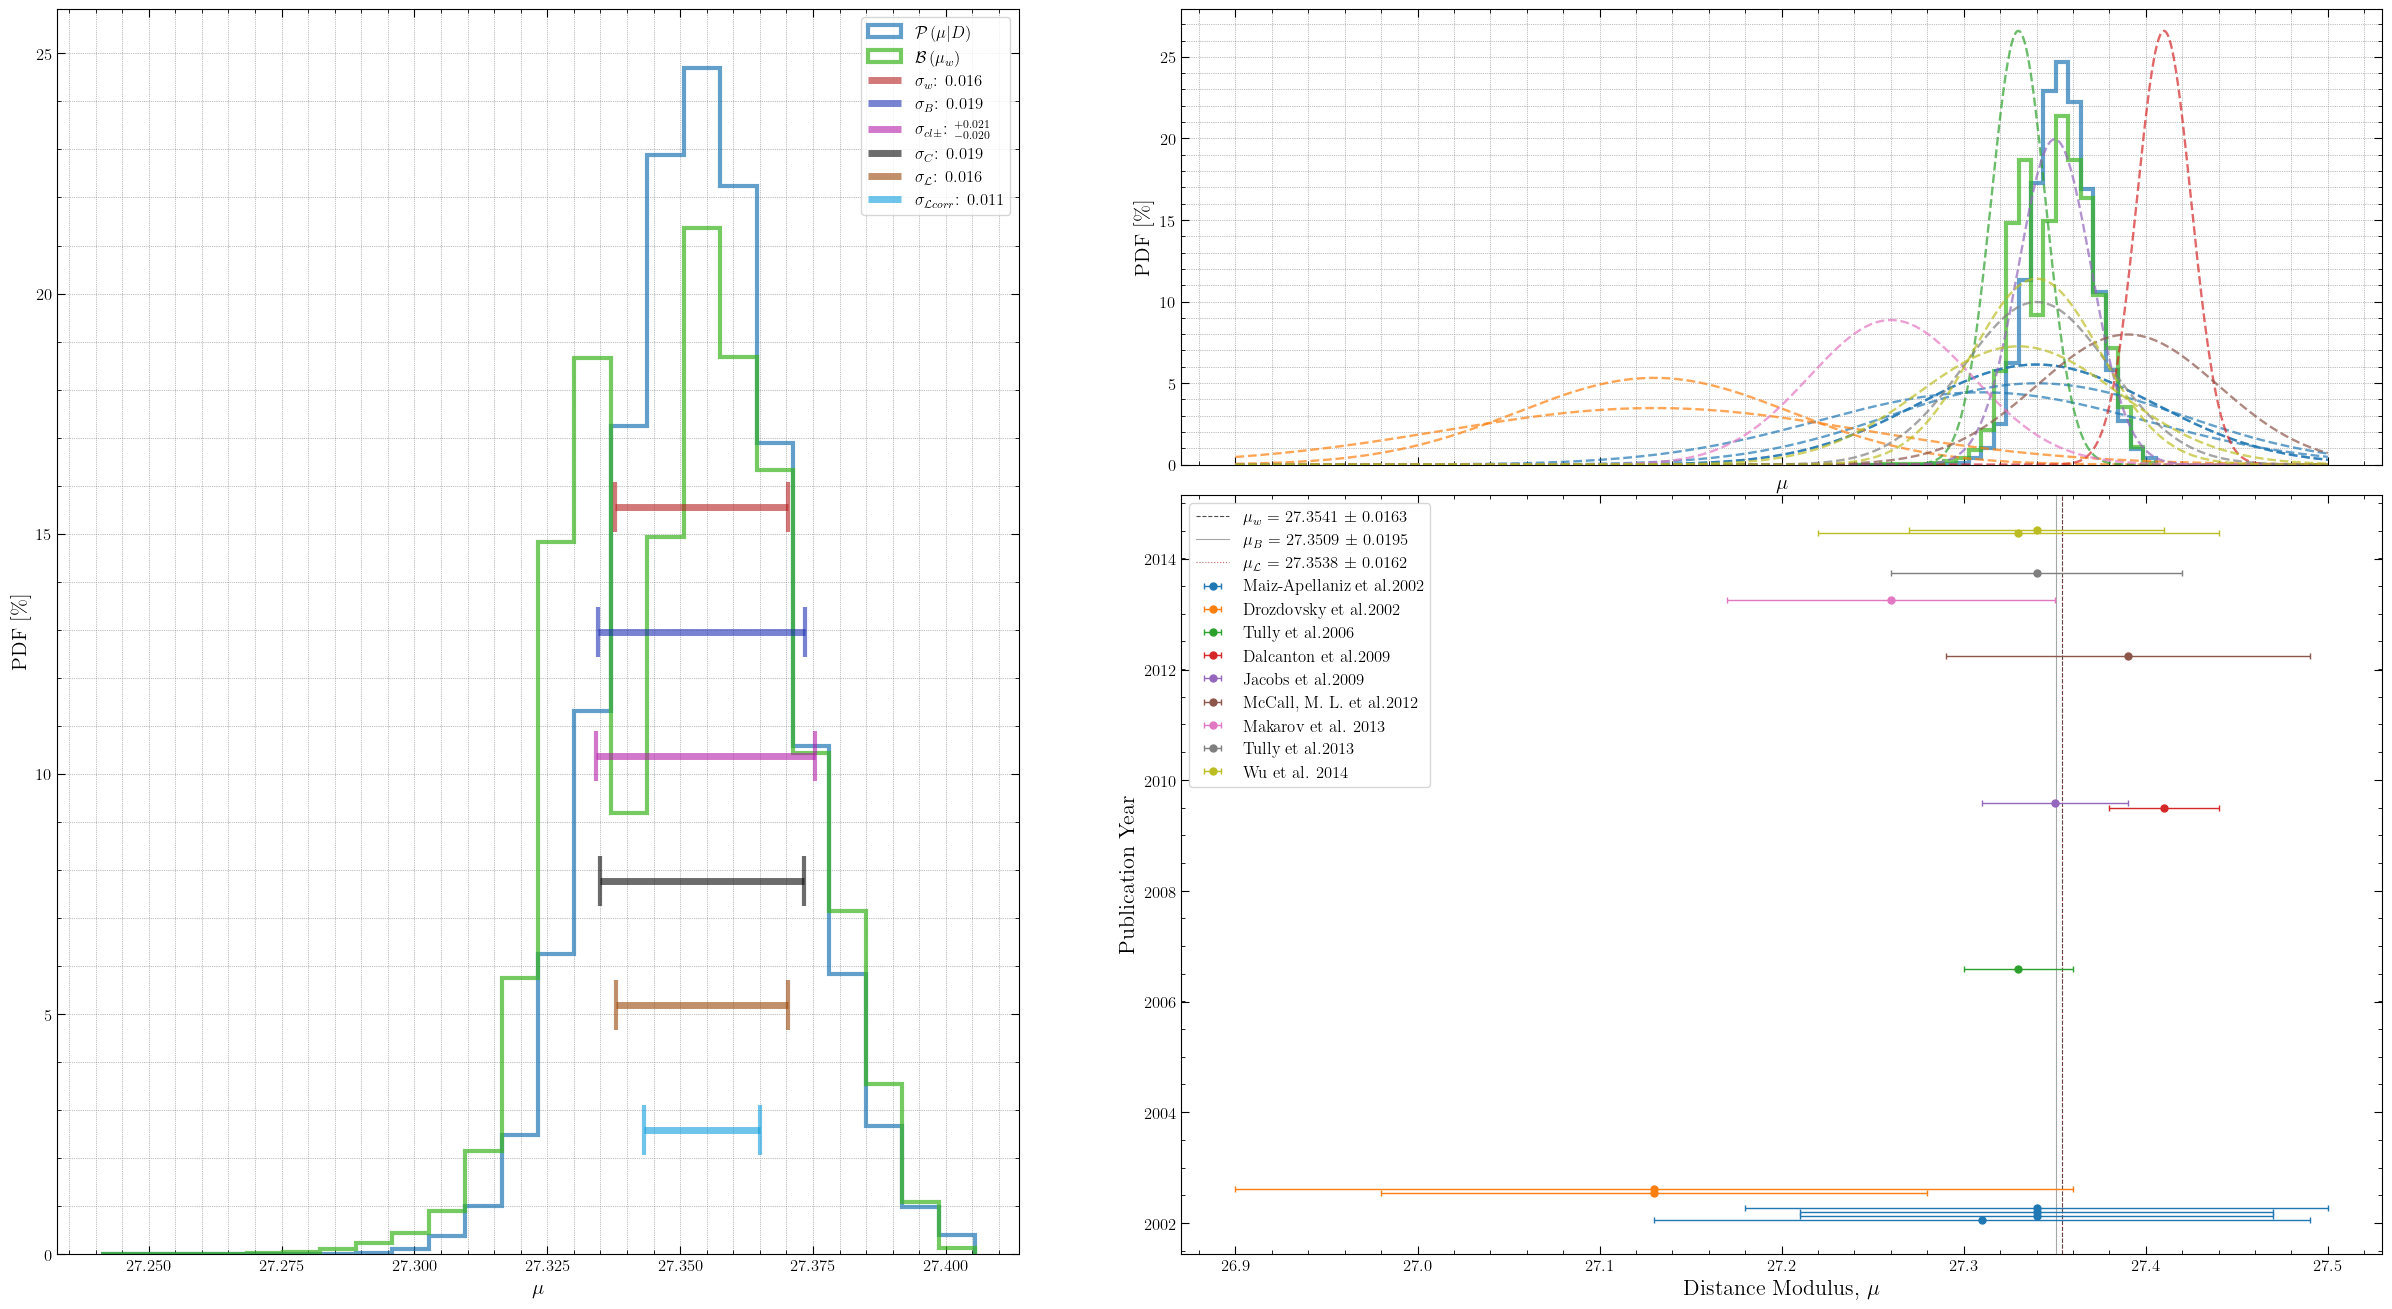

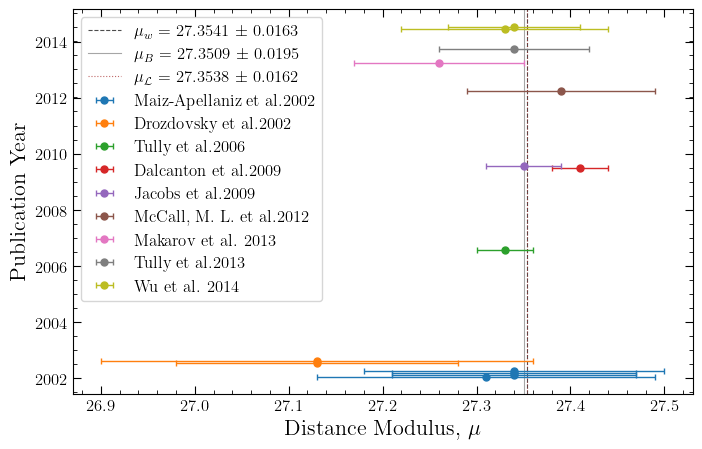

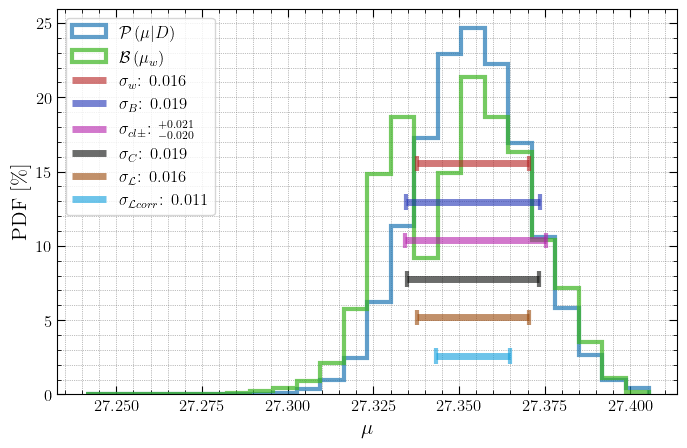

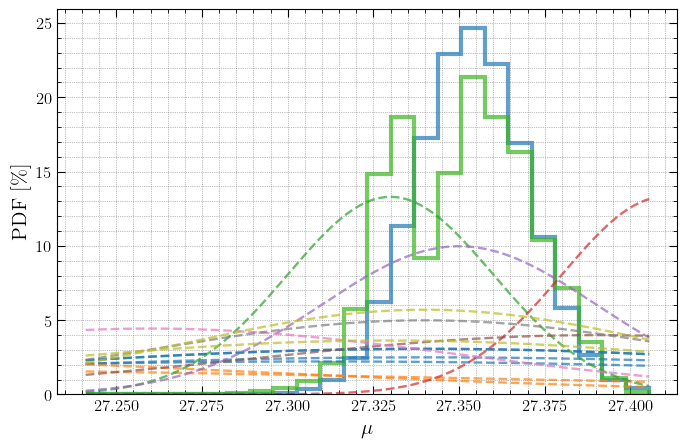

In [281]:
Ex  = moduli_stats_calculator(dataset='TRGB_eR.csv', galaxy_name='NGC4214')


<Axes: xlabel='$\\mu$', ylabel='PDF [$\\%$]'>

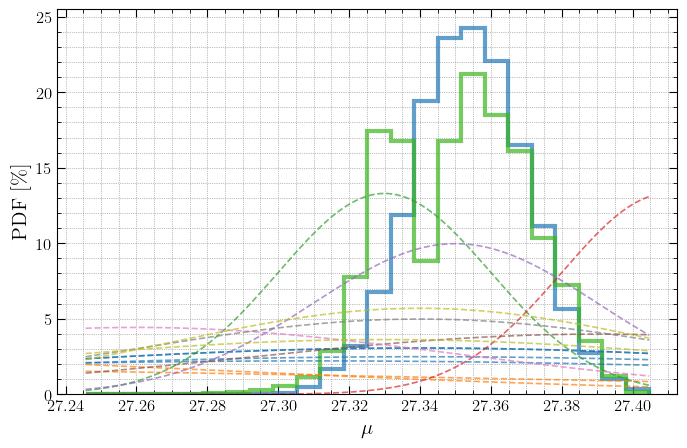

In [172]:
Ex.pdf_arts_plot()

<Axes: xlabel='$\\mu$', ylabel='PDF [$\\%$]'>

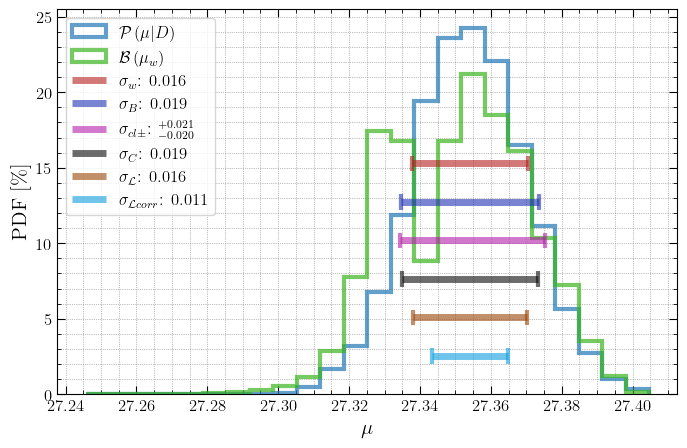

In [173]:
Ex.main_dist_plot()

<Axes: xlabel='Distance Modulus, $\\mu$', ylabel='Publication Year'>

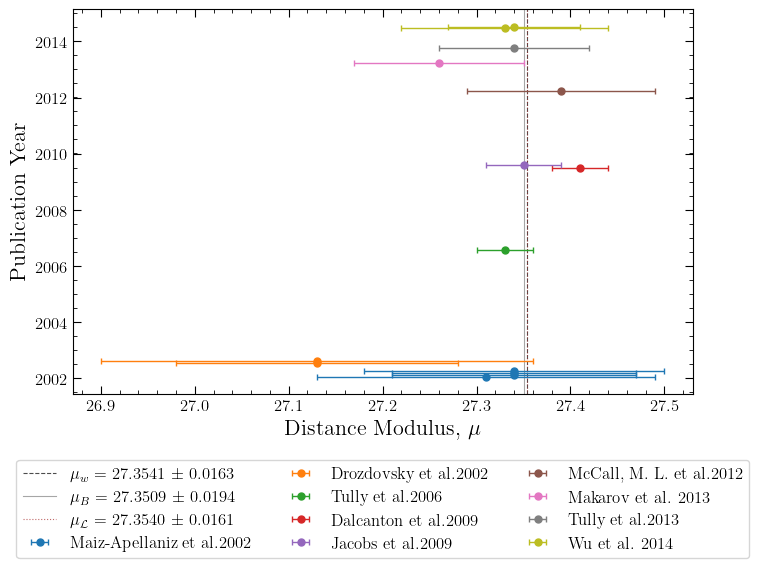

In [174]:
Ex.forest_plot()